In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('C:/Users/diyad/Desktop/HireSafe/src')

from signal_extraction.signals import SignalExtractor

# Load augmented data
train_aug = pd.read_csv('C:/Users/diyad/Desktop/HireSafe/data/train_augmented_final.csv')

# Extract signals
extractor = SignalExtractor()

print("Extracting signals from augmented dataset...")
signals_list = []

for idx, row in train_aug.iterrows():
    signals = extractor.extract_all_signals(row)
    signals_list.append(signals)
    
    if idx % 2000 == 0:
        print(f"Processed {idx}/{len(train_aug)}...")

signals_df = pd.DataFrame(signals_list)
train_with_signals = pd.concat([train_aug, signals_df], axis=1)

print("\n✓ Signal extraction complete!")

Extracting signals from augmented dataset...
Processed 0/16490...
Processed 2000/16490...
Processed 4000/16490...
Processed 6000/16490...
Processed 8000/16490...
Processed 10000/16490...
Processed 12000/16490...
Processed 14000/16490...
Processed 16000/16490...

✓ Signal extraction complete!


In [2]:
# Calculate signal statistics
print("="*80)
print("SIGNAL FREQUENCY ANALYSIS")
print("="*80)

for signal in signals_df.columns:
    total_count = train_with_signals[signal].sum()
    fraud_count = train_with_signals[train_with_signals['fraudulent'] == 1][signal].sum()
    legit_count = train_with_signals[train_with_signals['fraudulent'] == 0][signal].sum()
    
    fraud_rate_when_present = train_with_signals[train_with_signals[signal] == 1]['fraudulent'].mean()
    
    print(f"\n{signal.upper().replace('_', ' ')}:")
    print(f"  Total occurrences: {total_count} ({total_count/len(train_with_signals)*100:.1f}% of dataset)")
    print(f"  In fraudulent posts: {fraud_count}/{train_with_signals['fraudulent'].sum()} ({fraud_count/train_with_signals['fraudulent'].sum()*100:.1f}%)")
    print(f"  In legitimate posts: {legit_count}/{(1-train_with_signals['fraudulent']).sum()} ({legit_count/(1-train_with_signals['fraudulent']).sum()*100:.1f}%)")
    print(f"  ⭐ Fraud rate when signal present: {fraud_rate_when_present*100:.1f}%")

SIGNAL FREQUENCY ANALYSIS

PAYMENT REQUEST:
  Total occurrences: 3891 (23.6% of dataset)
  In fraudulent posts: 788/2879 (27.4%)
  In legitimate posts: 3103/13611 (22.8%)
  ⭐ Fraud rate when signal present: 20.3%

URGENCY:
  Total occurrences: 2119 (12.9% of dataset)
  In fraudulent posts: 808/2879 (28.1%)
  In legitimate posts: 1311/13611 (9.6%)
  ⭐ Fraud rate when signal present: 38.1%

OFFPLATFORM CONTACT:
  Total occurrences: 1164 (7.1% of dataset)
  In fraudulent posts: 812/2879 (28.2%)
  In legitimate posts: 352/13611 (2.6%)
  ⭐ Fraud rate when signal present: 69.8%

VAGUE COMPANY:
  Total occurrences: 4457 (27.0% of dataset)
  In fraudulent posts: 2255/2879 (78.3%)
  In legitimate posts: 2202/13611 (16.2%)
  ⭐ Fraud rate when signal present: 50.6%

SALARY ANOMALY:
  Total occurrences: 229 (1.4% of dataset)
  In fraudulent posts: 184/2879 (6.4%)
  In legitimate posts: 45/13611 (0.3%)
  ⭐ Fraud rate when signal present: 80.3%


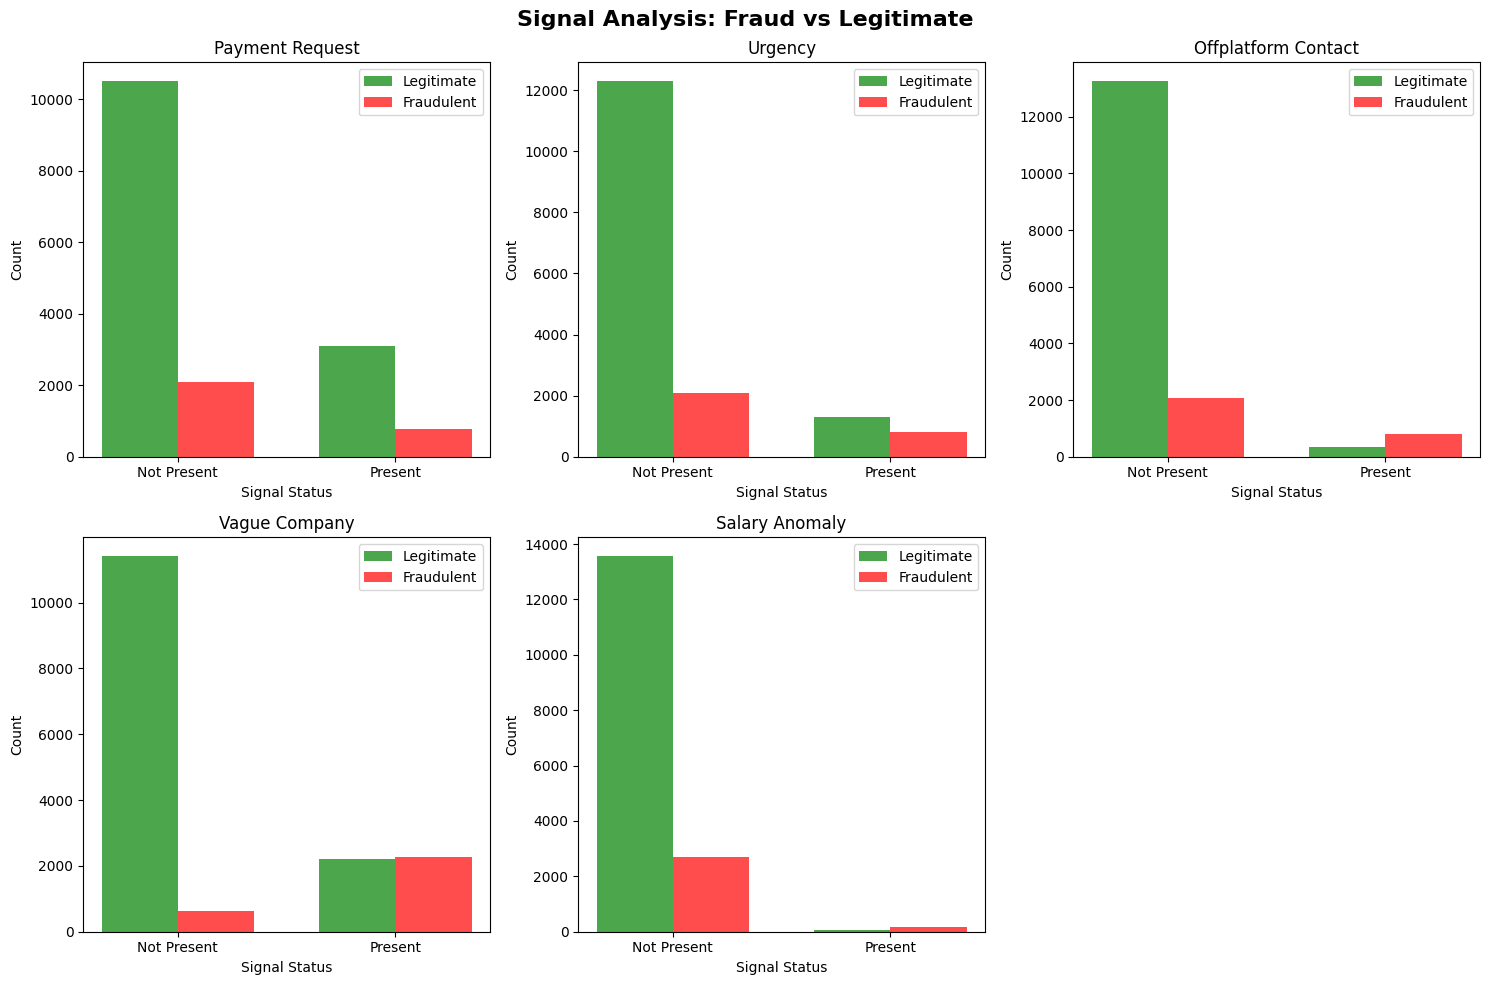

In [3]:
# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Signal Analysis: Fraud vs Legitimate', fontsize=16, fontweight='bold')

signals = signals_df.columns.tolist()

for idx, signal in enumerate(signals):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Count by fraud status
    fraud_data = train_with_signals[train_with_signals['fraudulent'] == 1][signal].value_counts()
    legit_data = train_with_signals[train_with_signals['fraudulent'] == 0][signal].value_counts()
    
    x = ['Not Present', 'Present']
    fraud_counts = [fraud_data.get(0, 0), fraud_data.get(1, 0)]
    legit_counts = [legit_data.get(0, 0), legit_data.get(1, 0)]
    
    x_pos = [0, 1]
    width = 0.35
    
    ax.bar([p - width/2 for p in x_pos], legit_counts, width, label='Legitimate', color='green', alpha=0.7)
    ax.bar([p + width/2 for p in x_pos], fraud_counts, width, label='Fraudulent', color='red', alpha=0.7)
    
    ax.set_xlabel('Signal Status')
    ax.set_ylabel('Count')
    ax.set_title(signal.replace('_', ' ').title())
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.legend()

# Remove empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

In [4]:
# Analyze combined signal strength
train_with_signals['total_signals'] = signals_df.sum(axis=1)

print("="*80)
print("SIGNAL COMBINATION ANALYSIS")
print("="*80)

for num_signals in range(6):
    subset = train_with_signals[train_with_signals['total_signals'] == num_signals]
    if len(subset) > 0:
        fraud_rate = subset['fraudulent'].mean()
        count = len(subset)
        
        print(f"\nPostings with {num_signals} red flags:")
        print(f"  Count: {count}")
        print(f"  Fraud rate: {fraud_rate*100:.1f}%")

SIGNAL COMBINATION ANALYSIS

Postings with 0 red flags:
  Count: 7936
  Fraud rate: 6.9%

Postings with 1 red flags:
  Count: 6784
  Fraud rate: 19.4%

Postings with 2 red flags:
  Count: 919
  Fraud rate: 22.1%

Postings with 3 red flags:
  Count: 274
  Fraud rate: 86.5%

Postings with 4 red flags:
  Count: 469
  Fraud rate: 99.8%

Postings with 5 red flags:
  Count: 108
  Fraud rate: 100.0%


In [5]:
# Save for Week 3
train_with_signals.to_csv('C:/Users/diyad/Desktop/HireSafe/data/train_final_with_signals.csv', index=False)

print("\n✓ Saved train_final_with_signals.csv")
print("\nThis dataset includes:")
print("  - All augmented data")
print("  - All 5 extracted signals")
print("  - Total signal count")
print("\nReady for Week 3: Baseline models and semantic similarity!")


✓ Saved train_final_with_signals.csv

This dataset includes:
  - All augmented data
  - All 5 extracted signals
  - Total signal count

Ready for Week 3: Baseline models and semantic similarity!
